### Gini

Gini Index:
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

General Gini:
$$Gini_{split} = \frac{|S_{left}|}{|S|} Gini(S_{left}) + \frac{|S_{right}|}{|S|} Gini(S_{right})$$

$Gini = 1 - ((6/8)^2 + (2/8)^2) = 0.375$

$Gini = 1 - ((3/6)^2 + (3/6)^2) = 0.5$

$$Gini_{Wind} = \frac{8}{14} \cdot 0.375 + \frac{6}{14} \cdot 0.5 \approx \mathbf{0.428}$$

$$Gini_{Outlook} = \left( \frac{5}{14} \cdot 0.48 \right) + \left( \frac{4}{14} \cdot 0 \right) + \left( \frac{5}{14} \cdot 0.48 \right)\approx \mathbf{0.3428}$$


<font color = green >

# Decision Trees
</font>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 

In [ ]:
%matplotlib inline 

<font color = green >

## Iris dataset 
</font>

In [ ]:
# Don't install graphviz with the help of pip, use conda install  graphviz
# !pip install graphviz

In [ ]:
# !conda install graphviz

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
from sklearn.model_selection import train_test_split
# Note: In case of RuntimeError "Make sure the Graphviz executables are on your system's path” after installing Graphviz 
# helps on mac:  brew install graphviz
# helps on windows:  import os
# os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'

In [ ]:
iris= load_iris()

iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

<font color = green >

## Learning the model
</font>

In [ ]:
max_depth = 3
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

In [ ]:
max_depth = 2
clf = DecisionTreeClassifier(
    criterion=  'gini',
    random_state=20,        
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

<font color = green >

## Vizualize the decision tree  graph 
</font>

In [ ]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=features,  
                                class_names=labels,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green >

## Feature importance
</font>

In [ ]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

In [ ]:
plot_feature_importances(clf, features)

<font color = green >

## Regressor
</font>

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [ ]:
X, y = make_regression(n_samples=500, n_features=5, noise=0.2, random_state=42)
features = ['Size', 'Year', 'Rooms', 'Location', 'Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=10).fit(X_train, y_train)

In [ ]:
print(f"Train R² Score: {reg_tree.score(X_train, y_train):.3%}")
print(f"Test R² Score:  {reg_tree.score(X_test, y_test):.3%}")

In [ ]:
from IPython.display import Image

dot_data = tree.export_graphviz(reg_tree, out_file=None, 
                                feature_names=features,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

Image(graph.pipe(format='png'), width=1900, height=1000)

In [ ]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(8, 5), dpi=80)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_, color='lightgreen', edgecolor='black')
    plt.xlabel("Feature Importance (Contribution to Variance Reduction)")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title("Decision Tree Regression: Feature Importances")
    plt.show()

In [ ]:
plot_feature_importances(reg_tree, features)

<font color = green >

## Auxiliary drawing functions 
</font>

In [ ]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True, title_size= None):

    '''    
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later 
    cmap_light = ListedColormap(colors_for_areas)
 
   
    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples 
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape 
    Z = Z.reshape(xx1.shape)
    
    if ax:
        plt.sca(ax)
    
    # Plot all meshgrid prediction      
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size, 
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size, 
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend  
        import matplotlib.patches as mpatches # use to assign lavels for colored points 
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    
    fontdict={'fontsize': title_size} if title_size else None
    
    plt.title(title, fontdict)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False, 
        labelbottom = False
        )

        
    
def plot_data_logistic_regression(X,y,legend_loc= None, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)

    
def plot_multi_class_logistic_regression(X,y,dict_names=None, colors= None,  title =None):
    '''
    Draw the multi class samples of 2 features
    :param X: X 2 ndarray (m,2),
    :param y: vector (m,)
    :param dict_names: dict of values of y and names
    :return: None
    '''
    if not colors:
        colors_for_points = ['green','grey', 'orange', 'brown']
    else:
         colors_for_points = colors

    y_unique = list(set(y))

    for i in range (len(y_unique)):
        ind = y == y_unique[i] # vector

        if dict_names:
            plt.scatter(X[ind,0], X[ind,1], c=colors_for_points[i], s=40, label=dict_names[y_unique[i]],edgecolor='black', alpha=.7)
        else:
            plt.scatter(X[ind, 0], X[ind, 1], s=40, c=colors_for_points [i], edgecolor = 'black', alpha = 0.7)
    if title:
        plt.title(title)

    if dict_names:
        plt.legend(frameon=True)
        


<font color = green >

## Synthetic dataset
</font>

In [ ]:
from sklearn.datasets import make_blobs

In [ ]:
X_mk8, y_mk8 = make_blobs(n_samples = 200, n_features = 2, centers = 8, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X_train = X_mk8
y_train = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]
plt.figure()
plot_data_logistic_regression(X_mk8,y_train)


In [ ]:
plt.figure(figsize= (10,3))
max_depths= [3,5,10]    

for i, max_depth in enumerate(max_depths):
    ax = plt.subplot(1,len(max_depths),i+1)
    clf = DecisionTreeClassifier(
        criterion=  'entropy',
        random_state=20,        
        max_depth=max_depth,    
    #     max_leaf_nodes=4,
    ).fit(X_train, y_train)
    accuracy = clf.score (X_train, y_train)
#     print("train accuracy= {:.3%}".format(accuracy))
    plot_decision_boundary(
        clf,
        X_train,
        y_train,
        precision= 0.05,
        ax=ax,
        title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy),
        is_extended= False,
        title_size= 11,)
    
plt.tight_layout (w_pad=-2)


# max_depth=5    
# clf = DecisionTreeClassifier(
#     criterion=  'entropy',
#     random_state=20,        
#     max_depth=max_depth,    
# #     max_leaf_nodes=4,
# ).fit(X_train, y_train)
# accuracy = clf.score (X_train, y_train)
# print("train accuracy= {:.3%}".format(accuracy))
# plt.figure()

# plot_decision_boundary(clf, X_train, y_train, precision= 0.05, title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy))

In [ ]:
# graph_viz = tree.export_graphviz(clf, out_file=None,filled = True)
# graph = graphviz.Source(graph_viz)
# graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

#### Should appear the followingf image in separate window 

<img src = "data/decision_tree_graph2.jpg" height=500 width= 500 align="left">

<div style="clear:left;"></div>
<br><br><br><br><br><br><br><br>


<font color = green >

## Tennis dataset

</font>

In [ ]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'tennis.csv')
fn=  'data/tennis.csv'
df = pd.read_csv(fn)
del df['temp']
print (df.head())

X_train = df.iloc[:, :3].values
y_train = df.iloc[:, 3].values
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)

In [ ]:
from sklearn.preprocessing  import LabelEncoder

In [ ]:
X_train_cat = X_train.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print ('{}: {}'.format(list(df)[i], le_dict))
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

In [ ]:
max_depth = None
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
    # max_leaf_nodes=4,
).fit(X_train_cat, y_train_cat)
features = list(df)[:3]
labels = ['No','Yes']

print("train accuracy= {:.3%}".format(clf.score (X_train_cat, y_train_cat)))

In [ ]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=list(features),  
                                class_names=[str(l) for l in labels],  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green>

#  Random Forests

</font>



In [ ]:
from sklearn.ensemble import RandomForestClassifier

<font color = green>

## Iris dataset

</font>



In [ ]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

In [ ]:
clf = RandomForestClassifier().fit (X_train, y_train)
clf.score (X_train, y_train)
n_estimators_list= [5,10,20]
max_features_list= list(np.arange(1, X_train.shape[1]+1))

for i in range (len(n_estimators_list)): 
    for j in range (len(max_features_list)):
        index = len(max_features_list)*i+j           
        clf = RandomForestClassifier(
            random_state=10,
            n_estimators= n_estimators_list[i],
            max_features=max_features_list[j],        
        ).fit(X_train, y_train)
        accuracy_train = clf.score (X_train, y_train)
        accuracy_test = clf.score (X_test, y_test)
        print ('n_estimators= {}, max_features = {}, accuracy_train = {:.3%}, accuracy_test = {:.3%}'.format (
            n_estimators_list[i],max_features_list[j], accuracy_train, accuracy_test))

In [ ]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test, y_test)))

In [ ]:
# Conclusion: this dataset is not good to demonstrate the power of random forest 

<font color = green>

## Mushrooms dataset

</font>



In [ ]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'mushrooms.csv')
fn= 'data/mushrooms.csv'
# https://www.kaggle.com/ymotonskillupai/mushroomscsv
df = pd.read_csv(fn)

print (list(df))
X = df.iloc[:, 1:].values
y = df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
df.head()

In [ ]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print (X_test[:,i])
    X_test_cat[:,i] = le.transform(X_test[:,i])
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
y_test_cat= le.transform(y_test)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

In [ ]:
max_features_list = [20,12, 10,8,6,4,3,2,1]    
for i, max_features in enumerate(max_features_list):
    clf = RandomForestClassifier(
        random_state=0,        
        max_features= max_features,    
    ).fit(X_train_cat, y_train_cat)
    accuracy_train = clf.score(X_train_cat, y_train_cat)
    accuracy_test = clf.score(X_test_cat, y_test_cat)
    print ('max_features = {}:\n\t accuracy_train = {:.3%}\n\t accuracy_test = {:.3%}'.format (
        max_features_list[i], accuracy_train, accuracy_test))

In [ ]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth,
).fit(X_train_cat, y_train_cat)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train_cat, y_train_cat)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test_cat, y_test_cat)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train_cat, y_train_cat)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train_cat, y_train_cat)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test_cat, y_test_cat)))

In [ ]:
# Conclusion: this dataset is also  not good to demonstrate the power of random forest :)

<font color = green >

# Gradient boosting decision tree
</font>

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

<font color = green>

## Fruits dataset 2D

</font>



In [ ]:
import os
cwd= os.getcwd() 
path = os.path.join(cwd,'data')
fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table(fn)
df_fruits.head(10)


In [ ]:
def plot_decision_boundary_universal(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.1,plot_symbol_size = 50, ax= None,  is_extended=True, labels= None, features =None):
    '''
    expected to be universal for binary and multiclass classification but not tested for binary 
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_areas= colors_for_points =  np.array(['green','grey', 'orange', 'brown'])
    cmap_light = ListedColormap(colors_for_areas)

    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    if precision<0.05:
        print ('Calling to predict for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        
        # Create legend
        if labels is None:
            labels= ['negative','positive'] # assume this is for binary or for muticlass with labels 
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patches= [mpatches.Patch(color=colors_for_points[i], label=labels[i]) for i in range (len(labels))]
        plt.legend(handles=patches)
        if features is None:
            plt.xlabel('feature 1')
            plt.ylabel('feature 2')
        else: 
            plt.xlabel(features[0])
            plt.ylabel(features[1])

    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )
    plt.title(title)


In [ ]:
features = ['width', 'height']
X = df_fruits[features].values
y = df_fruits['fruit_label'].values -1  # shift due to labels of fruits are from 1 

df_fruits.head(20)
# labels =  df_fruits['fruit_name'].unique()
fruits_dict = dict(zip(np.unique(y), df_fruits['fruit_name'].unique()))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)

print ('target names :', fruits_dict)

plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)


In [ ]:
plt.figure ()
labels =list(fruits_dict.values())

clf = GradientBoostingClassifier(learning_rate=0.01,max_depth=3).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
plot_decision_boundary_universal(clf, X_train, y_train, X_test, y_test, title='GradientBoostingClassifier', precision=0.05, labels= labels, features = features)


---

<font color = green>

##  XGBoost
</font>



In [ ]:
from xgboost import XGBClassifier

clf_xgboost = XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
clf_xgboost.fit(X_train, y_train)
print('\nAccuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf_xgboost.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf_xgboost.score(X_test, y_test)))



In [ ]:
help(XGBClassifier)

In [ ]:
X_mk8, y_mk8 = make_blobs(n_samples = 2000, n_features = 2, centers = 16, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X = X_mk8
y = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
plt.figure()
plot_data_logistic_regression(X_train,y_train)

In [ ]:
print(X_train.shape)
y_train.shape

In [ ]:
X_train

In [ ]:
common_max_depth = 3
seed = 10

print('='*30)
print('DECISION TREE')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=common_max_depth
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_dt.score(X_test, y_test)))

print('\n' + '='*30)
print('RANDOM FOREST')
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n' + '='*30)
print('GRADIENT BOOSTING')
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_gb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_gb.score(X_test, y_test)))

print('\n' + '='*30)
print('XGBOOST')
clf_xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    n_estimators=100,
    max_depth=common_max_depth, 
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_xgb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_xgb.score(X_test, y_test)))

<font color = green >
    
# Home Task 

</font>



<font color = green>

##  Brest cancer  dataset
</font>



In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)



X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree 

</font>



In [ ]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import graphviz 
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 100.000%
test accuracy= 91.608%


'Source.gv.pdf'

<font color = green>

##  RandomForest

</font>



In [8]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



In [9]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(random_state=0)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


<font color = green>

##  XGBoost

</font>



In [10]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from xgboost import XGBClassifier
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [19]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Classification:

In [ ]:
from sklearn.datasets import fetch_openml

data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame

df_income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,18.0,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K


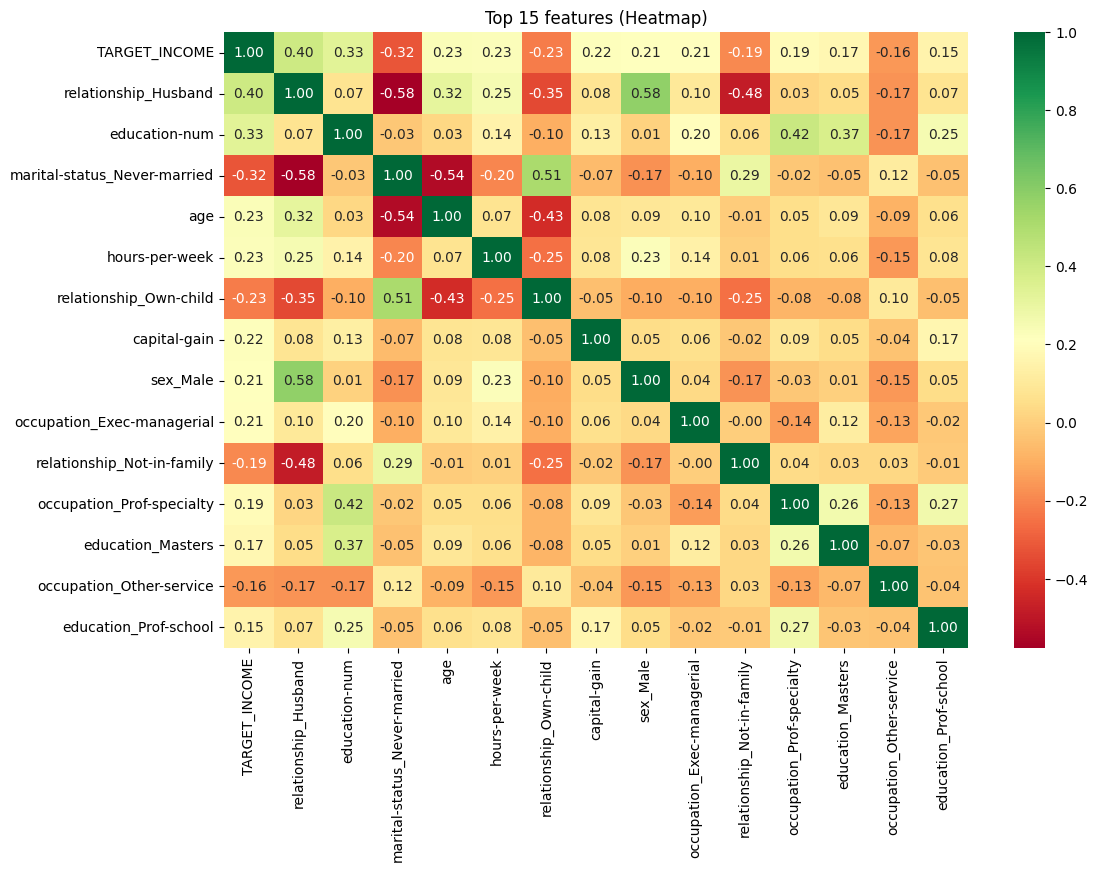

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X = pd.get_dummies(df_income.drop('class', axis=1), drop_first=True)

y = df_income['class'].map({df_income['class'].unique()[0]: 0, 
                             df_income['class'].unique()[1]: 1}).astype(int)

temp_df = X.copy()
temp_df['TARGET_INCOME'] = y.values
top_features = temp_df.corr()['TARGET_INCOME'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(temp_df[top_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Top 15 features (Heatmap)')
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = XGBClassifier(
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], 
    verbose=True                
)

[0]	validation_0-logloss:0.63933
[1]	validation_0-logloss:0.59520
[2]	validation_0-logloss:0.55847
[3]	validation_0-logloss:0.52756
[4]	validation_0-logloss:0.50141
[5]	validation_0-logloss:0.47824
[6]	validation_0-logloss:0.45886
[7]	validation_0-logloss:0.44219
[8]	validation_0-logloss:0.42755
[9]	validation_0-logloss:0.41421
[10]	validation_0-logloss:0.40303
[11]	validation_0-logloss:0.39324
[12]	validation_0-logloss:0.38428
[13]	validation_0-logloss:0.37668
[14]	validation_0-logloss:0.36950
[15]	validation_0-logloss:0.36312
[16]	validation_0-logloss:0.35742
[17]	validation_0-logloss:0.35220
[18]	validation_0-logloss:0.34770
[19]	validation_0-logloss:0.34355
[20]	validation_0-logloss:0.33950
[21]	validation_0-logloss:0.33632
[22]	validation_0-logloss:0.33332
[23]	validation_0-logloss:0.33039
[24]	validation_0-logloss:0.32799
[25]	validation_0-logloss:0.32554
[26]	validation_0-logloss:0.32327
[27]	validation_0-logloss:0.32134
[28]	validation_0-logloss:0.31947
[29]	validation_0-loglos

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=500, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1] 

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

print(f"True Positives  (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives  (TN): {tn}")
print(f"False Negatives (FN): {fn}")

Accuracy:  0.8783
Precision: 0.7816
Recall:    0.6672
F1-score:  0.7199
ROC AUC:   0.9327
True Positives  (TP): 1528
False Positives (FP): 427
True Negatives  (TN): 7052
False Negatives (FN): 762


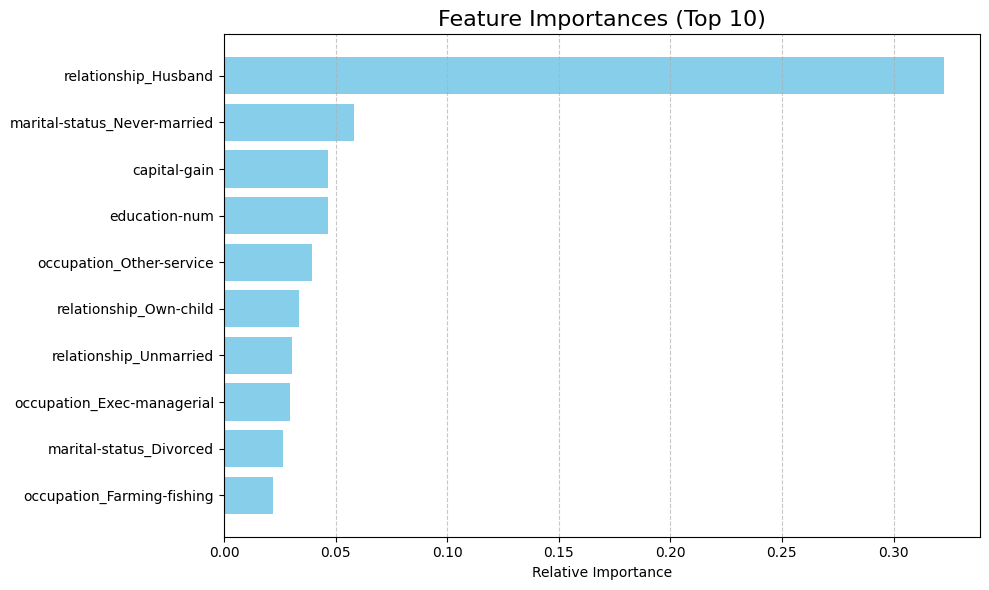

In [51]:
import matplotlib.pyplot as plt
import numpy as np

importances = clf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Top 10)", fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### <h1>Regression</h1>

In [59]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,60.0,RL,65.0,8450.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,2.0,2008.0,WD,Normal,208500.0
1,2.0,20.0,RL,80.0,9600.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,5.0,2007.0,WD,Normal,181500.0
2,3.0,60.0,RL,68.0,11250.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,9.0,2008.0,WD,Normal,223500.0
3,4.0,70.0,RL,60.0,9550.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,2.0,2006.0,WD,Abnorml,140000.0
4,5.0,60.0,RL,84.0,14260.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,12.0,2008.0,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456.0,60.0,RL,62.0,7917.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,8.0,2007.0,WD,Normal,175000.0
1456,1457.0,20.0,RL,85.0,13175.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,MnPrv,None,0.0,2.0,2010.0,WD,Normal,210000.0
1457,1458.0,70.0,RL,66.0,9042.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,GdPrv,Shed,2500.0,5.0,2010.0,WD,Normal,266500.0
1458,1459.0,20.0,RL,68.0,9717.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,4.0,2010.0,WD,Normal,142125.0


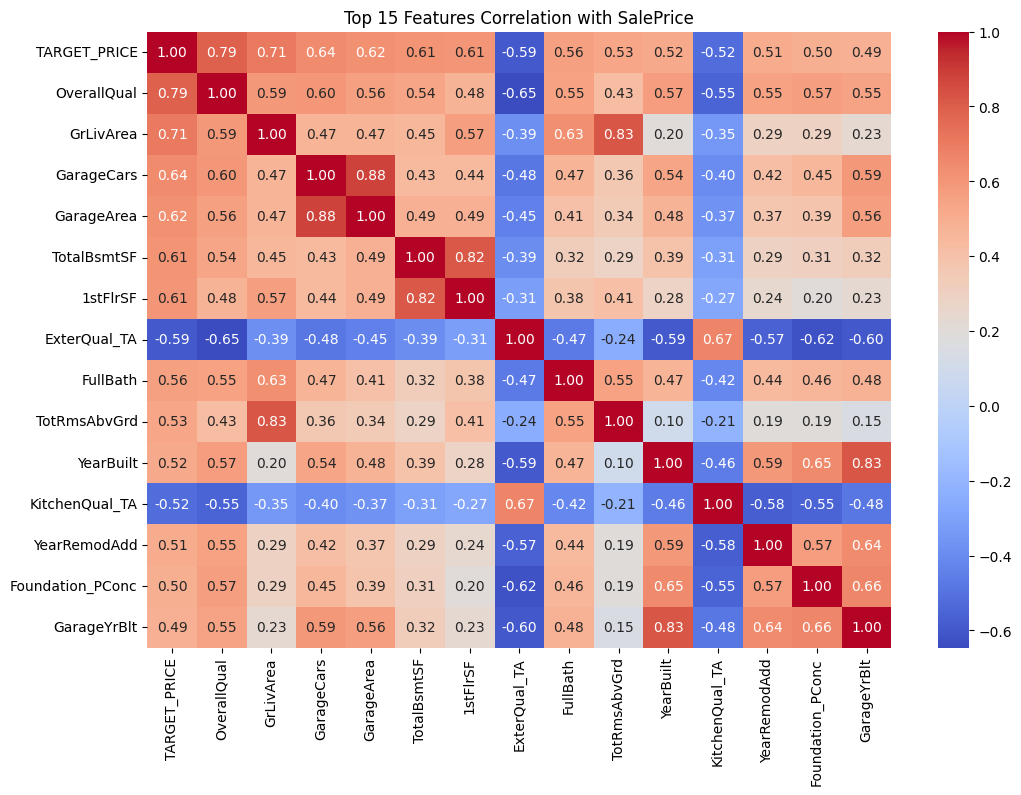

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X_house = pd.get_dummies(df_house.drop('SalePrice', axis=1), drop_first=True)
y_house = df_house['SalePrice']

temp_house = X_house.copy()
temp_house['TARGET_PRICE'] = y_house.values

top_corr = temp_house.corr()['TARGET_PRICE'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(temp_house[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlation with SalePrice')
plt.show()

In [61]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

reg = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

reg.fit(
    X_train_h, y_train_h,
    eval_set=[(X_test_h, y_test_h)],
    eval_metric='rmse',
    verbose=True
)


[0]	validation_0-rmse:181023.32241
[1]	validation_0-rmse:164479.78384
[2]	validation_0-rmse:149726.86302
[3]	validation_0-rmse:136906.64302
[4]	validation_0-rmse:125304.75537
[5]	validation_0-rmse:115046.45159
[6]	validation_0-rmse:105527.11262
[7]	validation_0-rmse:97222.78662
[8]	validation_0-rmse:89471.34562
[9]	validation_0-rmse:82675.57230
[10]	validation_0-rmse:76826.71697
[11]	validation_0-rmse:71457.89847
[12]	validation_0-rmse:66626.25474
[13]	validation_0-rmse:62148.95704
[14]	validation_0-rmse:58366.86756
[15]	validation_0-rmse:55008.18646
[16]	validation_0-rmse:51988.62263
[17]	validation_0-rmse:49264.86858
[18]	validation_0-rmse:46987.60741
[19]	validation_0-rmse:44835.10116
[20]	validation_0-rmse:43039.40364
[21]	validation_0-rmse:41411.19128
[22]	validation_0-rmse:40058.79183
[23]	validation_0-rmse:38842.60271
[24]	validation_0-rmse:37616.64355
[25]	validation_0-rmse:36707.94291
[26]	validation_0-rmse:35803.04910
[27]	validation_0-rmse:35283.46805
[28]	validation_0-rmse:

C:\Users\gulya\AppData\Roaming\Python\Python37\site-packages\xgboost\sklearn.py:797: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  UserWarning,


[34]	validation_0-rmse:32379.21672
[35]	validation_0-rmse:32222.44493
[36]	validation_0-rmse:31956.30092
[37]	validation_0-rmse:31744.56055
[38]	validation_0-rmse:31561.02109
[39]	validation_0-rmse:31438.45997
[40]	validation_0-rmse:31317.49364
[41]	validation_0-rmse:31239.13750
[42]	validation_0-rmse:31172.90888
[43]	validation_0-rmse:31074.00295
[44]	validation_0-rmse:30995.84063
[45]	validation_0-rmse:30912.36744
[46]	validation_0-rmse:30872.35739
[47]	validation_0-rmse:30808.35062
[48]	validation_0-rmse:30750.71251
[49]	validation_0-rmse:30739.24053
[50]	validation_0-rmse:30694.42942
[51]	validation_0-rmse:30673.55150
[52]	validation_0-rmse:30631.36851
[53]	validation_0-rmse:30558.14644
[54]	validation_0-rmse:30500.69425
[55]	validation_0-rmse:30455.69638
[56]	validation_0-rmse:30429.74804
[57]	validation_0-rmse:30383.27464
[58]	validation_0-rmse:30357.58764
[59]	validation_0-rmse:30333.47132
[60]	validation_0-rmse:30329.98929
[61]	validation_0-rmse:30305.58846
[62]	validation_0-rm

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=500, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, max_error
import numpy as np

y_pred_h = reg.predict(X_test_h)

r2 = r2_score(y_test_h, y_pred_h)
mae = mean_absolute_error(y_test_h, y_pred_h)
mse = mean_squared_error(y_test_h, y_pred_h)
rmse = np.sqrt(mse)
med_ae = median_absolute_error(y_test_h, y_pred_h)
max_err = max_error(y_test_h, y_pred_h)
mape = np.mean(np.abs((y_test_h - y_pred_h) / y_test_h)) * 100

print(f"R2 Score (Accuracy):     {r2:.4f}")
print(f"MAE (Mean Absolute Err): {mae:.2f}")
print(f"RMSE (Root MSE):         {rmse:.2f}")
print(f"Median Absolute Error:   {med_ae:.2f}")
print(f"Maximum Error:           {max_err:.2f}")
print(f"MAPE (Percentage Error): {mape:.2f}%")

R2 Score (Accuracy):     0.8856
MAE (Mean Absolute Err): 16900.35
RMSE (Root MSE):         29616.69
Median Absolute Error:   10384.24
Maximum Error:           280365.62
MAPE (Percentage Error): 10.09%


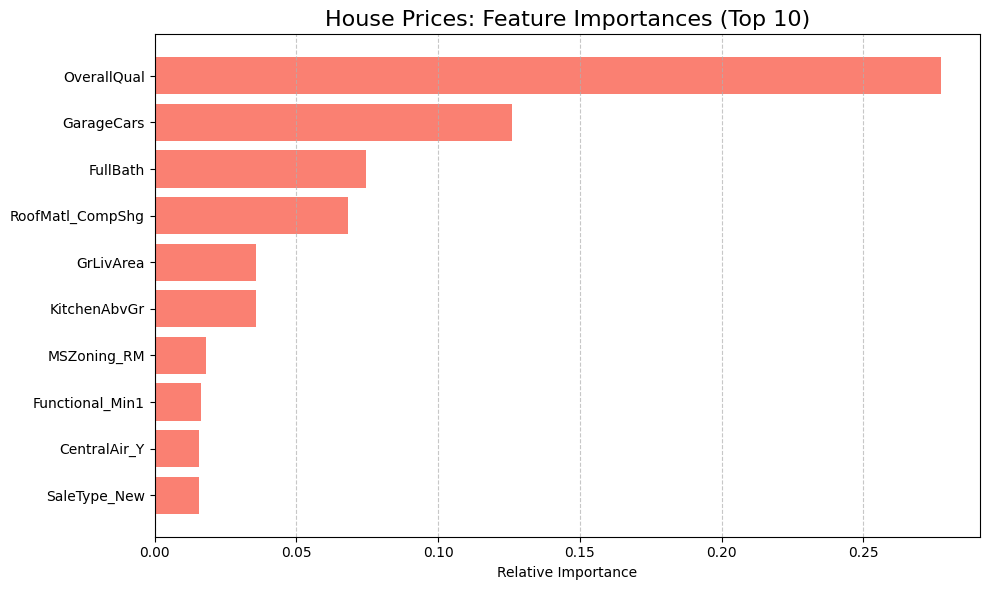

In [63]:
importances_h = reg.feature_importances_
feature_names_h = X_house.columns
indices_h = np.argsort(importances_h)[-10:]

plt.figure(figsize=(10, 6))
plt.title("House Prices: Feature Importances (Top 10)", fontsize=16)
plt.barh(range(len(indices_h)), importances_h[indices_h], color='salmon', align='center')
plt.yticks(range(len(indices_h)), [feature_names_h[i] for i in indices_h])
plt.xlabel("Relative Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()